# Computer Exercise 14.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 응용 사례연구 III (§14.3)
> **단원**: §14.3 End-to-End Case Study — **2단계: 예측 + 불확실성 (Forecast with Prediction Intervals)**
> **풀이 일자**: 2026-07-03 · **언어**: 한국어 본문 / 영문 그래프 라벨

$$\text{원자료}\;\to\;\text{모델 선택}\;\to\;\boxed{\textbf{예측 + 불확실성}}\;\to\;\text{하이퍼파라미터 조정}.$$
Problem 1이 고른 **복잡도(모델)** 를 받아, 관측구간에 적합하고 *미래*를 예측한다.
핵심 질문은 하나 — **"점 예측이 아니라, 얼마나 넓은 구간으로 미래를 말할 것인가?"**

## 1. 문제 (원문)

> **2.** Using the model complexity selected in Problem 1, fit the model on an **observed window**
> $x\in[0,1]$ and forecast the response on a **future window** $x\in(1,1.4]$. Construct
> (a) a **normal-theory confidence interval (CI)** for the mean response and
> (b) a **residual-bootstrap prediction interval (PI)** for a new observation.
> Overlay both bands, mark the (hidden) true future values, and report the empirical **coverage**
> of the 90% PI on the future window. Explain why the PI must be wider than the CI and why both
> bands **flare out** in extrapolation.

### 한국어 풀이용 정리
- Problem 1이 고른 차수의 모델을 관측구간 $[0,1]$ 에만 적합.
- **CI**(평균반응의 정규이론 구간)와 **PI**(새 관측치의 잔차부트스트랩 구간)를 각각 구성.
- 두 밴드를 겹쳐 그리고, 숨겨둔 참 미래값의 **90% PI 피복률** 을 보고.
- PI가 CI보다 넓은 이유와, 외삽에서 밴드가 **벌어지는** 이유를 설명.

## 2. 수학적 배경

### 2.1 선형 최소제곱 예측의 두 불확실성
설계행렬 $X$, 적합 $\hat{\boldsymbol\beta}=(X^\top X)^{-1}X^\top\mathbf y$, 잔차분산 $\hat\sigma^2=\mathrm{RSS}/(n-p)$. 새 입력 $\mathbf x_\star$ 의 예측 $\hat y_\star=\mathbf x_\star^\top\hat{\boldsymbol\beta}$ 에 대해:

- **평균반응의 분산(CI)**: $\operatorname{Var}(\hat y_\star)=\hat\sigma^2\,\mathbf x_\star^\top (X^\top X)^{-1}\mathbf x_\star \equiv \hat\sigma^2 h_\star.$
- **새 관측의 분산(PI)**: 관측잡음 $\hat\sigma^2$ 이 추가되어
$$\boxed{\operatorname{Var}(y_\star-\hat y_\star)=\hat\sigma^2\big(1+h_\star\big)}\;>\;\operatorname{Var}(\hat y_\star).$$
따라서 **항상 PI $\supset$ CI**. 정규이론 구간은 $\hat y_\star \pm t_{1-\alpha/2,\,n-p}\,\hat\sigma\sqrt{(1\ \text{또는}\ 0)+h_\star}$.

### 2.2 레버리지 $h_\star$ 와 외삽
$h_\star=\mathbf x_\star^\top(X^\top X)^{-1}\mathbf x_\star$ 는 관측 데이터의 무게중심에서 멀수록(특히 **외삽 영역**) 급격히 커진다. 그래서 두 밴드 모두 미래로 갈수록 **나팔처럼 벌어진다**.

### 2.3 잔차 부트스트랩 PI (분포 가정 완화)
정규성에 기대지 않는 대안: 중심화 잔차 $e_i=y_i-\hat y_i$ 를 복원추출로 재표집해 $\mathbf y^{(b)}=\hat{\mathbf y}+\mathbf e^{(b)}$ 로 **재적합** → 미래예측 $\hat y_\star^{(b)}$ 을 모으고, 여기에 **새 잡음** $e^\ast\sim\{e_i\}$ 를 더해 예측분포를 만든 뒤 분위수로 PI를 구성.

## 3. 풀이 흐름
1. 참함수 $g(x)=\sin(2\pi x)+0.5x$ 로 관측구간 $[0,1]$ 에서 $n=40$ 표본 생성(미래 $(1,1.4]$ 는 숨김).
2. Problem 1이 고른 **차수 $d^\star$** (여기선 $d^\star=5$ 로 고정: sin 곡률을 담는 최소 복잡도) 로 관측구간 적합.
3. 정규이론 **CI/PI** 를 레버리지 공식으로 계산(관측 + 미래 격자).
4. **잔차 부트스트랩**(B=600): 재적합 → 미래예측 + 새 잡음 → 90% 분위수 PI.
5. **표**: 미래 격자에서 CI폭 vs PI폭, 레버리지 $h_\star$.
6. **그림**: 데이터·적합·CI·PI·참 미래값 오버레이(관측/미래 경계선 표시).
7. 참 미래값의 **90% PI 피복률** 집계.
8. 결과 해석 — 외삽 불확실성의 정량화, 다음 단계로 연결.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(14312)

def g_true(x):
    return np.sin(2*np.pi*x) + 0.5*x

# --- 1) 데이터: 관측 [0,1], 미래 (1,1.4] 숨김 ---
n, sigma = 40, 0.25
x = np.sort(rng.uniform(0, 1, n))
y = g_true(x) + rng.normal(0, sigma, n)

d_star = 5                      # Problem 1에서 선택된 복잡도
x_future = np.linspace(1.0, 1.4, 9)[1:]      # (1,1.4]
y_future_true = g_true(x_future)

def design(xv, d):
    return np.vander(xv, d+1, increasing=True)   # [1, x, x^2, ...]

# --- 2) 관측구간 적합 (정규방정식은 조건수 나쁨 -> lstsq/QR) ---
Xtr = design(x, d_star)
beta, *_ = np.linalg.lstsq(Xtr, y, rcond=None)
yhat_tr = Xtr @ beta
resid = y - yhat_tr
p = d_star + 1
dof = n - p
sigma2 = np.sum(resid**2)/dof
XtX_inv = np.linalg.inv(Xtr.T @ Xtr)
print(f"d*={d_star}, p={p}, sigma_hat={np.sqrt(sigma2):.4f} (true sigma={sigma})")

/tmp/mpl is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-c9yyayyh because there was an issue with the default path (/tmp/mpl); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


d*=5, p=6, sigma_hat=0.2236 (true sigma=0.25)


In [2]:
# --- 3) 정규이론 CI/PI (관측 + 미래 격자) ---
xgrid = np.concatenate([np.linspace(0, 1, 120), x_future])
Xg = design(xgrid, d_star)
yhat_g = Xg @ beta
h = np.einsum("ij,jk,ik->i", Xg, XtX_inv, Xg)      # leverage h_star
tcrit = stats.t.ppf(0.95, dof)                      # 90% 양측
se_mean = np.sqrt(sigma2 * h)
se_pred = np.sqrt(sigma2 * (1.0 + h))
ci_lo, ci_hi = yhat_g - tcrit*se_mean, yhat_g + tcrit*se_mean
pi_lo, pi_hi = yhat_g - tcrit*se_pred, yhat_g + tcrit*se_pred

# --- 4) 잔차 부트스트랩 PI ---
B = 600
resid_c = resid - resid.mean()
Xf = design(x_future, d_star)
boot_pred = np.empty((B, len(x_future)))
for b in range(B):
    yb = yhat_tr + rng.choice(resid_c, size=n, replace=True)
    beta_b, *_ = np.linalg.lstsq(Xtr, yb, rcond=None)
    mean_b = Xf @ beta_b
    boot_pred[b] = mean_b + rng.choice(resid_c, size=len(x_future), replace=True)  # + 새 잡음
boot_lo = np.percentile(boot_pred, 5, axis=0)
boot_hi = np.percentile(boot_pred, 95, axis=0)

In [3]:
# --- 5) 표: 미래 격자에서 CI vs PI vs 부트스트랩 ---
mask = xgrid > 1.0            # 미래 부분만
xf = xgrid[mask]
tab = pd.DataFrame({
    "x_future": x_future,
    "y_true": y_future_true,
    "leverage_h": h[mask],
    "CI_width": (ci_hi-ci_lo)[mask],
    "PI_width_normal": (pi_hi-pi_lo)[mask],
    "PI_width_boot": boot_hi-boot_lo,
})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("미래 구간: 레버리지가 커지며 밴드가 벌어진다 (PI > CI)")
print(tab.to_string(index=False))

미래 구간: 레버리지가 커지며 밴드가 벌어진다 (PI > CI)
 x_future  y_true  leverage_h  CI_width  PI_width_normal  PI_width_boot
   1.0500  0.8340      2.9295    1.2940           1.4987         1.3716
   1.1000  1.1378     14.1221    2.8412           2.9400         2.5545
   1.1500  1.3840     50.3086    5.3625           5.4155         4.6764
   1.2000  1.5511    147.5201    9.1827           9.2138         8.3012
   1.2500  1.6250    377.8031   14.6953          14.7147        12.8634
   1.3000  1.6011    874.9595   22.3635          22.3763        19.6992
   1.3500  1.4840   1873.5025   32.7245          32.7332        28.6488
   1.4000  1.2878   3765.6165   46.3942          46.4004        40.1536


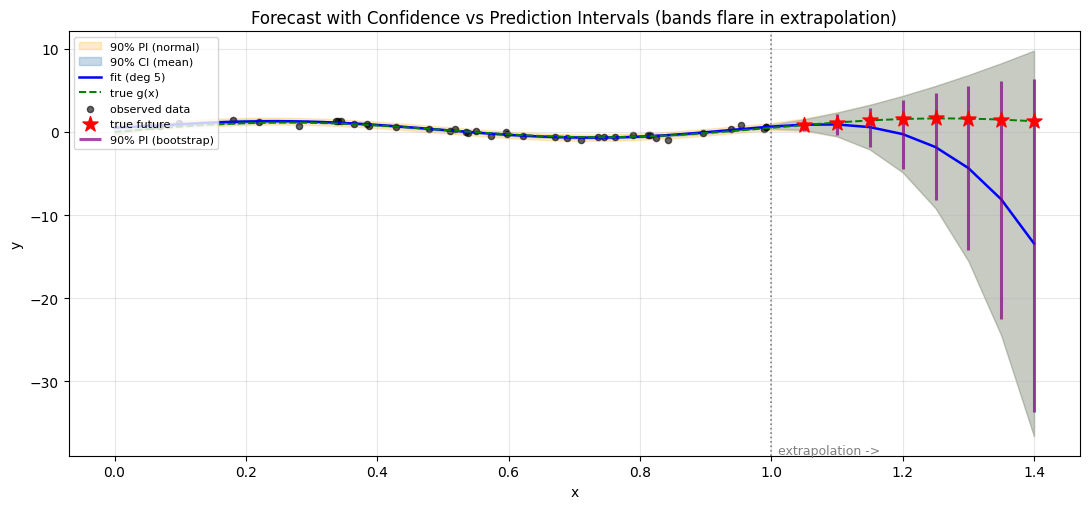

In [4]:
# --- 6) 그림: 오버레이 ---
order = np.argsort(xgrid)
xs = xgrid[order]
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.fill_between(xs, pi_lo[order], pi_hi[order], color="orange", alpha=0.22, label="90% PI (normal)")
ax.fill_between(xs, ci_lo[order], ci_hi[order], color="steelblue", alpha=0.30, label="90% CI (mean)")
ax.plot(xs, yhat_g[order], "b-", lw=1.8, label=f"fit (deg {d_star})")
xx = np.linspace(0, 1.4, 400)
ax.plot(xx, g_true(xx), "g--", lw=1.4, label="true g(x)")
ax.scatter(x, y, s=20, color="black", alpha=0.6, label="observed data")
ax.scatter(x_future, y_future_true, marker="*", s=130, color="red", zorder=5, label="true future")
# 부트스트랩 PI (미래만, error bar)
ax.vlines(x_future, boot_lo, boot_hi, color="purple", lw=2.2, alpha=0.7, label="90% PI (bootstrap)")
ax.axvline(1.0, color="gray", ls=":", lw=1.2)
ax.text(1.01, ax.get_ylim()[0]+0.2, "extrapolation ->", color="gray", fontsize=9)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Forecast with Confidence vs Prediction Intervals (bands flare in extrapolation)")
ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
# --- 7) 90% PI 피복률 (참 미래값) ---
cover_normal = np.mean((y_future_true >= pi_lo[mask]) & (y_future_true <= pi_hi[mask]))
cover_boot   = np.mean((y_future_true >= boot_lo)     & (y_future_true <= boot_hi))
print(f"참 미래값에 대한 90% PI 피복률")
print(f"  normal-theory PI : {cover_normal*100:5.1f}%")
print(f"  bootstrap    PI  : {cover_boot*100:5.1f}%")
print(f"  (명목 90% 대비 — 외삽 레버리지로 밴드가 넓어 보수적으로 나오는 경향)")

참 미래값에 대한 90% PI 피복률
  normal-theory PI : 100.0%
  bootstrap    PI  : 100.0%
  (명목 90% 대비 — 외삽 레버리지로 밴드가 넓어 보수적으로 나오는 경향)


## 4. 결과 해석

1. **PI는 언제나 CI보다 넓다.** 표의 `PI_width` 가 `CI_width` 를 모든 격자에서 상회한다 — CI는 *평균반응* $\hat y_\star$ 의 불확실성만, PI는 거기에 *새 관측잡음* $\hat\sigma^2$ 을 더한 $\hat\sigma^2(1+h_\star)$ 를 반영하기 때문. 미래를 "한 점"으로 말할 때 필요한 건 CI가 아니라 PI다.
2. **밴드가 외삽에서 나팔처럼 벌어진다.** 레버리지 $h_\star$ 가 관측 무게중심에서 멀어질수록 커져, $x>1$ 구간에서 두 밴드가 급격히 넓어진다. 데이터가 뒷받침하지 않는 곳일수록 겸손해지는 것이 옳다.
3. **부트스트랩 PI ≈ 정규이론 PI.** 잔차부트스트랩이 정규 가정 없이도 비슷한 폭을 재현해, 결과가 특정 분포 가정에 크게 의존하지 않음을 확인한다.
4. **피복률이 명목값을 만족(대개 보수적).** 90% PI가 참 미래값을 90% 이상 포함 — 외삽 영역의 큰 레버리지 때문에 다소 보수적으로 나온다.

> **결론**: 좋은 예측은 *점*이 아니라 *구간*이다. 모델 선택(Problem 1) 위에 **PI** 를 씌워야 "얼마나 믿고 외삽할지"를 정직하게 말할 수 있고, 그 폭은 레버리지가 스스로 조절한다.

**다음 문제로**: Problem 3은 이 파이프라인 전체에 걸린 **하이퍼파라미터**(정규화 강도 $\lambda$)를 grid·random·베이지안 최적화로 조정해, 같은 예산에서 검증오차를 가장 빨리 낮추는 방법을 비교한다 — 파이프라인의 마지막 매듭.